In [37]:
import matplotlib.pyplot as plt
import japanize_matplotlib

In [38]:
from thinkbayes import _DictWrapper

class Pmf(_DictWrapper):

    def Normalize(self, fraction=1.0):
        if self.log:
            raise ValueError("Pmf is under a log transforms")
        total = self.Total()
        if total == 0.0:
            raise ValueError("total probability is zero")
            return total
        factor = float(fraction)/total
        for x in self.d:
            self.d[x] *=factor
        return total

class Suite(Pmf):
    def Update(self, data):
        for hypo in list(self.Values()):
            like = self.Likelihood(data, hypo)
            self.Mult(hypo, like)
        return self.Normalize()


In [39]:
class Dice(Suite):
    def Likelihood(self, data, hypo):
        if hypo < data:
            return 0
        else:
            return 1.0/hypo

(4, 6, 8, 12, 20)
(0.0, 0.392156862745098, 0.29411764705882354, 0.196078431372549, 0.11764705882352942)


Text(0.5, 1.0, 'Dice')

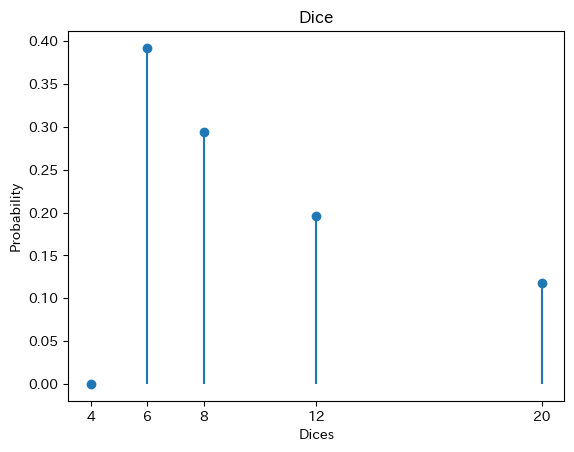

In [40]:
suite = Dice([4,6,8,12,20])
suite.Update(6)

k, v = zip(*suite.Items())

print(k)
print(v)
plt.vlines(k,0,v)
plt.plot(k,v, 'o')
plt.xlabel('Dices')
plt.ylabel('Probability')
plt.xticks([4, 6, 8, 12, 20])
plt.title("Dice")

(4, 6, 8, 12, 20)
(0.0, 0.0, 0.9432484536722124, 0.055206128061290875, 0.001545418266496554)


Text(0.5, 1.0, 'サイコロ問題')

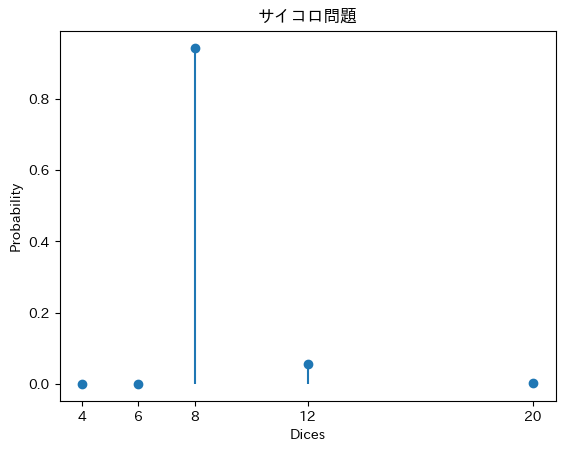

In [41]:
suite = Dice([4,6,8,12,20])

for roll in [6,6,8,7,7,5,4]:
    suite.Update(roll)

k, v = zip(*suite.Items())

print(k)
print(v)
plt.vlines(k,0,v)
plt.plot(k,v, 'o')
plt.xlabel('Dices')
plt.ylabel('Probability')
plt.xticks([4, 6, 8, 12, 20])
plt.title("サイコロ問題")